
========== SOCIAL MEDIA DATA ==========
  Post_ID          DateTime    User  \
0    P001  2026-08-01 09:15  Ananya   
1    P002  2026-08-01 18:30   Rahul   
2    P003  2026-08-01 12:10   Priya   
3    P004  2026-08-01 20:45   Arjun   
4    P005  2026-08-02 10:20  Ananya   

                                           Post_Text  Likes  Comments  Shares  \
0  AI is changing the future of work! #AI #Techno...    125        18      10   
1        Great cricket match today! #Cricket #Sports    210        35      22   
2  Healthy food makes a healthy life. #Health #Fi...     95        14       8   
3  Amazing new web development tools! #WebDev #Co...    180        27      15   
4    Learning Python is so much fun! #Python #Coding    240        32      18   

     Category  
0  Technology  
1      Sports  
2      Health  
3  Technology  
4   Education  

Dataset Shape:
(40, 8)

========== DATA CLEANING ==========

Missing Values:
Post_ID      0
DateTime     0
User         0
Post_Text    0
Lik

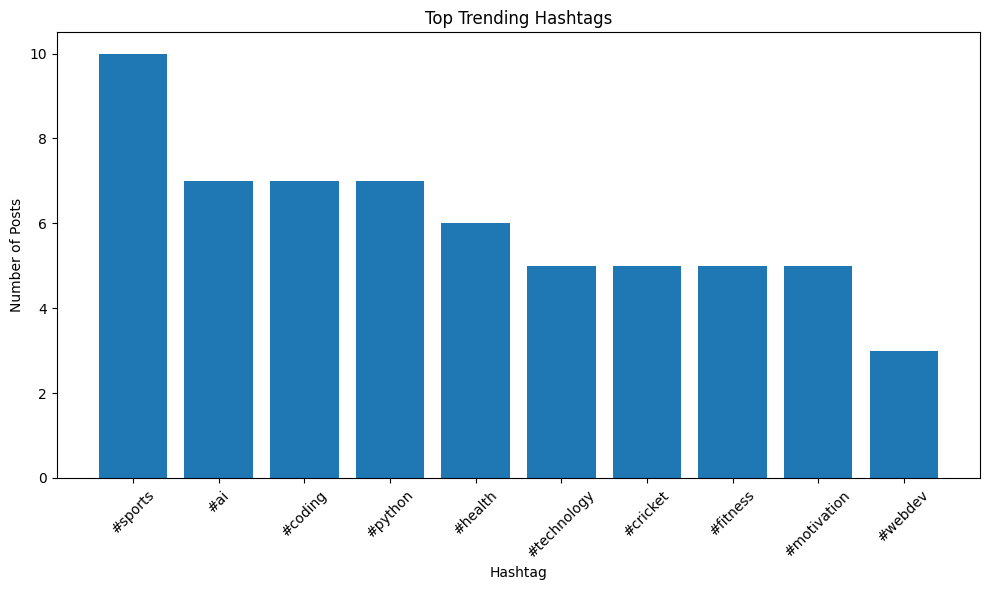

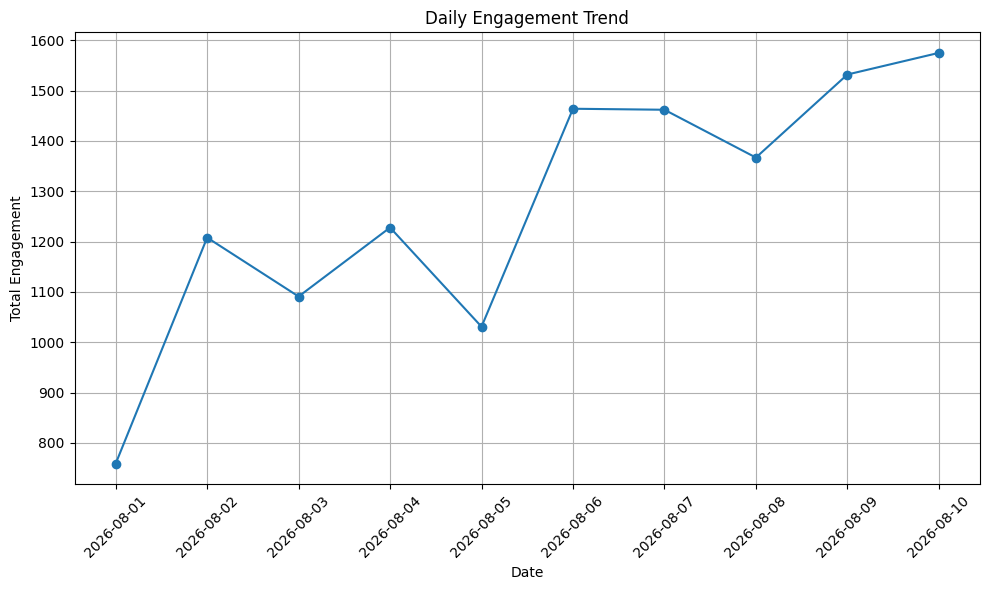

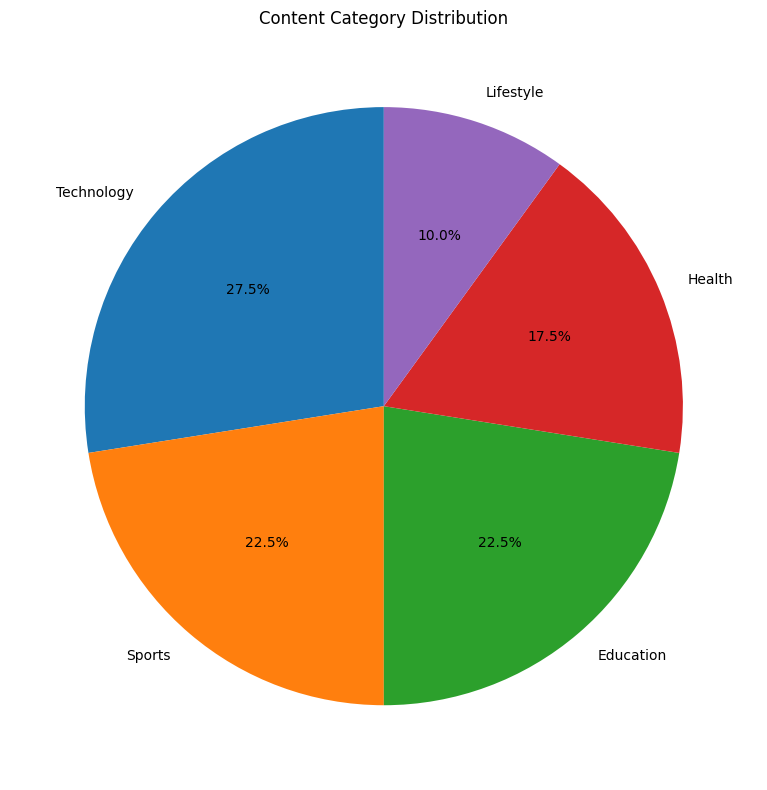


========== SENTIMENT ANALYSIS ==========
Sentiment
Neutral     23
Positive    15
Negative     2
Name: count, dtype: int64

✅ Analytics report exported!
File: analytics_report.csv

========== FINAL SUMMARY ==========
Total Posts: 40
Total Engagement: 12717
Most Active User: Ananya
Most Popular Posting Hour: 18 :00
Top Hashtag: #sports
Most Popular Category: Technology

🎉 SOCIAL MEDIA ANALYTICS COMPLETED!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re


# ==========================================
# 1. READ CSV FILE
# ==========================================

df = pd.read_csv("social_media_posts.csv")

print("\n========== SOCIAL MEDIA DATA ==========")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


# ==========================================
# 2. DATA CLEANING
# ==========================================

print("\n========== DATA CLEANING ==========")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.dropna()

# Convert DateTime
df["DateTime"] = pd.to_datetime(df["DateTime"])

# Create separate Date column
df["Date"] = df["DateTime"].dt.date

# Create posting hour
df["Hour"] = df["DateTime"].dt.hour


# ==========================================
# 3. EXTRACT HASHTAGS
# ==========================================

def extract_hashtags(text):

    return re.findall(
        r"#\w+",
        text
    )


df["Hashtags"] = df["Post_Text"].apply(
    extract_hashtags
)


# ==========================================
# 4. TOP TRENDING HASHTAGS
# ==========================================

hashtag_list = []

for hashtags in df["Hashtags"]:

    for hashtag in hashtags:

        hashtag_list.append(
            hashtag.lower()
        )


hashtag_counts = pd.Series(
    hashtag_list
).value_counts()


print("\n========== TOP TRENDING HASHTAGS ==========")

print(
    hashtag_counts.head(10)
)


# ==========================================
# 5. MOST ACTIVE USERS
# ==========================================

active_users = (
    df["User"]
    .value_counts()
)

print("\n========== MOST ACTIVE USERS ==========")

print(active_users)


# ==========================================
# 6. CALCULATE ENGAGEMENT
# ==========================================

df["Engagement"] = (
    df["Likes"]
    + df["Comments"]
    + df["Shares"]
)


print("\n========== ENGAGEMENT ==========")

print(
    df[
        [
            "Post_ID",
            "User",
            "Likes",
            "Comments",
            "Shares",
            "Engagement"
        ]
    ].head(10)
)


# ==========================================
# 7. MOST POPULAR POSTING TIME
# ==========================================

popular_hour = (
    df["Hour"]
    .value_counts()
    .idxmax()
)

popular_hour_count = (
    df["Hour"]
    .value_counts()
    .max()
)

print("\n========== POPULAR POSTING TIME ==========")

print(
    "Most popular posting hour:",
    popular_hour,
    ":00"
)

print(
    "Number of posts:",
    popular_hour_count
)


# ==========================================
# 8. TOP HASHTAGS CHART
# ==========================================

top_hashtags = hashtag_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_hashtags.index,
    top_hashtags.values
)

plt.title("Top Trending Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_hashtags_chart.png"
)

plt.show()


# ==========================================
# 9. DAILY ENGAGEMENT TREND
# ==========================================

daily_engagement = (
    df.groupby("Date")["Engagement"]
    .sum()
)


plt.figure(figsize=(10, 6))

plt.plot(
    daily_engagement.index,
    daily_engagement.values,
    marker="o"
)

plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Total Engagement")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "daily_engagement_trend.png"
)

plt.show()


# ==========================================
# 10. CONTENT CATEGORY DISTRIBUTION
# ==========================================

category_counts = (
    df["Category"]
    .value_counts()
)


plt.figure(figsize=(8, 8))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Content Category Distribution")

plt.tight_layout()

plt.savefig(
    "content_category_distribution.png"
)

plt.show()


# ==========================================
# 11. SENTIMENT ANALYSIS
# ==========================================

positive_words = [
    "great",
    "amazing",
    "wonderful",
    "happy",
    "exciting",
    "fantastic",
    "brilliant",
    "incredible",
    "positive",
    "love",
    "best"
]

negative_words = [
    "bad",
    "sad",
    "hate",
    "worst",
    "problem",
    "angry",
    "disappointing"
]


def sentiment_analysis(text):

    text = text.lower()

    positive_count = 0
    negative_count = 0

    for word in positive_words:

        if word in text:
            positive_count += 1

    for word in negative_words:

        if word in text:
            negative_count += 1

    if positive_count > negative_count:

        return "Positive"

    elif negative_count > positive_count:

        return "Negative"

    else:

        return "Neutral"


df["Sentiment"] = df["Post_Text"].apply(
    sentiment_analysis
)


print("\n========== SENTIMENT ANALYSIS ==========")

print(
    df["Sentiment"].value_counts()
)


# ==========================================
# 12. CREATE ANALYTICS REPORT
# ==========================================

report = df[
    [
        "Post_ID",
        "DateTime",
        "User",
        "Category",
        "Likes",
        "Comments",
        "Shares",
        "Engagement",
        "Sentiment"
    ]
]


report.to_csv(
    "analytics_report.csv",
    index=False
)


print(
    "\n✅ Analytics report exported!"
)

print(
    "File: analytics_report.csv"
)


# ==========================================
# 13. FINAL SUMMARY
# ==========================================

print("\n========== FINAL SUMMARY ==========")

print(
    "Total Posts:",
    len(df)
)

print(
    "Total Engagement:",
    df["Engagement"].sum()
)

print(
    "Most Active User:",
    active_users.idxmax()
)

print(
    "Most Popular Posting Hour:",
    popular_hour,
    ":00"
)

print(
    "Top Hashtag:",
    hashtag_counts.index[0]
)

print(
    "Most Popular Category:",
    category_counts.index[0]
)

print("\n🎉 SOCIAL MEDIA ANALYTICS COMPLETED!")